# 全 ETF 除息事件 Alpha 掃描

本 Notebook 的研究目標：

> 在已經有 `etf_daily_panel.csv` 與 `etf_dividend_events.csv` 的前提下，系統性檢驗「台灣 ETF 是否在除息前存在事件型 alpha」。

研究重點不是只看高股息 ETF，而是擴大到全部 ETF，並用 **同 ETF、同年份、非除息期間 matched placebo** 作為對照組，避免被 0050 / AI 多頭 / 不同 ETF 體質干擾。

## 核心問題

1. 所有 ETF 除息前是否有顯著正報酬？
2. 除息前報酬是否顯著高於「同 ETF 同年份非除息期間」？
3. 哪個窗口最有效：`-5→-1`、`-10→-1`、`-20→-1`、`-30→-1`、`-50→-1`？
4. 哪些 ETF 或 ETF 類型最有除息事件 alpha？
5. 初步可以形成哪些候選策略？

## 0. 匯入套件與設定路徑

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

PANEL_PATH = PROJECT_ROOT / "data" / "processed" / "etf_daily_panel.csv"
EVENTS_PATH = PROJECT_ROOT / "data" /  "processed"  / "etf_dividend_events.csv"

OUTPUT_DIR = PROJECT_ROOT / "data" / "research"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PANEL_PATH exists:", PANEL_PATH.exists(), PANEL_PATH)
print("EVENTS_PATH exists:", EVENTS_PATH.exists(), EVENTS_PATH)

C:\Users\USER\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\USER\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
C:\Users\USER\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


PROJECT_ROOT: C:\Users\USER\Desktop\ETF-alpha-lab
PANEL_PATH exists: True C:\Users\USER\Desktop\ETF-alpha-lab\data\processed\etf_daily_panel.csv
EVENTS_PATH exists: True C:\Users\USER\Desktop\ETF-alpha-lab\data\processed\etf_dividend_events.csv


## 1. 讀取資料

In [2]:
panel_all = pd.read_csv(PANEL_PATH, dtype={"symbol": str})
event_summary = pd.read_csv(EVENTS_PATH, dtype={"symbol": str})


def fix_tw_etf_symbol(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    symbol_fix_map = {
        "713": "00713",
        "0713": "00713",
        "878": "00878",
        "0878": "00878",
        "919": "00919",
        "0919": "00919",
        "929": "00929",
        "0929": "00929",
        "939": "00939",
        "0939": "00939",
        "940": "00940",
        "0940": "00940",
        "6208": "006208",
    }

    if s in symbol_fix_map:
        return symbol_fix_map[s]

    if len(s) <= 4:
        return s.zfill(4)

    return s


panel_all["symbol"] = panel_all["symbol"].apply(fix_tw_etf_symbol)
event_summary["symbol"] = event_summary["symbol"].apply(fix_tw_etf_symbol)


for col in ["date"]:
    if col in panel_all.columns:
        panel_all[col] = pd.to_datetime(panel_all[col], errors="coerce")

for col in ["ex_date", "record_date", "pay_date", "announcement_date"]:
    if col in event_summary.columns:
        event_summary[col] = pd.to_datetime(event_summary[col], errors="coerce")


panel_all = (
    panel_all
    .dropna(subset=["symbol", "date"])
    .sort_values(["symbol", "date"])
    .reset_index(drop=True)
)

event_summary = (
    event_summary
    .dropna(subset=["symbol", "ex_date"])
    .sort_values(["symbol", "ex_date"])
    .reset_index(drop=True)
)


print("panel_all shape:", panel_all.shape)
print("panel date range:", panel_all["date"].min(), "to", panel_all["date"].max())
print("panel symbol count:", panel_all["symbol"].nunique())
print("panel symbols:", sorted(panel_all["symbol"].unique()))

print("event_summary shape:", event_summary.shape)
print("event date range:", event_summary["ex_date"].min(), "to", event_summary["ex_date"].max())
print("event symbol count:", event_summary["symbol"].nunique())
print("event symbols:", sorted(event_summary["symbol"].unique()))

display(panel_all.head())
display(event_summary.head())

panel_all shape: (16224, 19)
panel date range: 2016-01-04 00:00:00 to 2026-05-18 00:00:00
panel symbol count: 10
panel symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']
event_summary shape: (208, 9)
event date range: 2016-05-04 00:00:00 to 2026-06-18 00:00:00
event symbol count: 10
event symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']


,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,nav_change,nav_change_pct,market_price,premium_discount,close_to_nav,market_price_to_nav,close_ret,nav_ret,price_nav_ret_spread
0,2016-01-04,0050,15.2000,15.2375,14.7625,14.8875,10.816450,67712252,59.34,61.22,-1.88,-0.0307,59.55,0.0035,-0.749115,0.003539,NaN,NaN,NaN
1,2016-01-05,0050,14.8750,14.9375,14.7125,14.7625,10.725632,87135876,59.01,59.34,-0.33,-0.0056,59.05,0.0007,-0.749831,0.000678,-0.008396,-0.005561,-0.002835
2,2016-01-06,0050,14.7625,14.7625,14.4750,14.6125,10.616649,115758200,58.31,59.01,-0.70,-0.0119,58.45,0.0024,-0.749400,0.002401,-0.010161,-0.011862,0.001702
3,2016-01-07,0050,14.5750,14.5750,14.1750,14.3375,10.416849,159849204,57.37,58.31,-0.94,-0.0161,57.35,-0.0003,-0.750087,-0.000349,-0.018820,-0.016121,-0.002699
4,2016-01-08,0050,14.2500,14.4250,14.2125,14.3625,10.435015,101802936,57.48,57.37,0.11,0.0019,57.45,-0.0005,-0.750130,-0.000522,0.001744,0.001917,-0.000174


,symbol,etf_name,ex_date,record_date,pay_date,dividend,source,source_url,scraped_at
0,0050,元大台灣50,2016-07-28,2016-08-03,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4
1,0050,元大台灣50,2017-02-08,2017-02-14,2017-03-14,1.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:25.8
2,0050,元大台灣50,2017-07-31,2017-08-06,2017-08-31,0.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:25.7
3,0050,元大台灣50,2018-01-29,2018-02-04,2018-03-13,2.20,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:27.4
4,0050,元大台灣50,2018-07-23,2018-07-29,2018-08-27,0.70,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:27.4


## 2. 欄位檢查與 ETF Universe 設定

這裡會先做基本欄位檢查，並建立全 ETF universe。

如果資料內有 `etf_name` 或 `fund_name`，會嘗試用名稱排除槓桿、反向、期貨型 ETF；如果沒有名稱欄位，則先保留全部 ETF，之後再用人工分類補強。

In [3]:
required_panel_cols = ["symbol", "date", "adj_close"]
required_event_cols = ["symbol", "ex_date"]

missing_panel = [c for c in required_panel_cols if c not in panel_all.columns]
missing_event = [c for c in required_event_cols if c not in event_summary.columns]

if missing_panel:
    raise ValueError(f"panel_all missing required columns: {missing_panel}")
if missing_event:
    raise ValueError(f"event_summary missing required columns: {missing_event}")

name_col = None
for candidate in ["etf_name", "fund_name", "name"]:
    if candidate in panel_all.columns:
        name_col = candidate
        break
if name_col is None:
    for candidate in ["etf_name", "fund_name", "name"]:
        if candidate in event_summary.columns:
            name_col = candidate
            break

print("Detected ETF name column:", name_col)

if name_col and name_col in panel_all.columns:
    etf_info = panel_all[["symbol", name_col]].drop_duplicates("symbol").copy()
elif name_col and name_col in event_summary.columns:
    etf_info = event_summary[["symbol", name_col]].drop_duplicates("symbol").copy()
else:
    etf_info = panel_all[["symbol"]].drop_duplicates().copy()
    etf_info["etf_name"] = ""
    name_col = "etf_name"

exclude_keywords = [
    "正2", "反1", "反向", "槓桿", "期貨", "VIX", "期信",
    "2X", "Bear", "Bull", "Inverse", "Leveraged"
]

etf_info["name_for_filter"] = etf_info[name_col].astype(str)
etf_info["is_excluded_by_name"] = etf_info["name_for_filter"].apply(
    lambda x: any(k in x for k in exclude_keywords)
)

valid_symbols = sorted(
    set(etf_info.loc[~etf_info["is_excluded_by_name"], "symbol"])
    & set(event_summary["symbol"])
    & set(panel_all["symbol"])
)

print("valid symbol count:", len(valid_symbols))
print("valid symbols:", valid_symbols)

print("valid symbol count:", len(valid_symbols))
display(etf_info.head(20))

Detected ETF name column: etf_name
valid symbol count: 10
valid symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']
valid symbol count: 10


,symbol,etf_name,name_for_filter,is_excluded_by_name
0,0050,元大台灣50,元大台灣50,False
20,0052,富邦科技,富邦科技,False
31,0056,元大高股息,元大高股息,False
50,006208,富邦台50,富邦台50,False
69,00713,元大台灣高息低波,元大台灣高息低波,False
89,00878,國泰永續高股息,國泰永續高股息,False
112,00919,群益台灣精選高息,群益台灣精選高息,False
125,00929,復華台灣科技優息,復華台灣科技優息,False
161,00939,統一台灣高息動能,統一台灣高息動能,False
184,00940,元大台灣價值高息,元大台灣價值高息,False


## 3. 建立全 ETF 除息事件視窗資料

這一步會從：

- `panel_all`：每日 ETF 價格資料
- `event_summary`：ETF 除息事件資料

建立出每一個事件的相對日資料，例如 `relative_day = -60, ..., -1, 0, ..., +10`。

In [4]:
def build_all_etf_event_data(
    panel_all: pd.DataFrame,
    event_summary: pd.DataFrame,
    symbols: list[str],
    window_before: int = 60,
    window_after: int = 10,
    price_col: str = "adj_close",
    allow_next_trading_day_match: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build event-window data for all ETF dividend events.

    relative_day is trading-day based:
    - -10 means 10 ETF trading days before ex-date
    - -1 means 1 ETF trading day before ex-date
    - 0 means ex-date if matched to trading day
    """

    event_rows = []
    skipped_rows = []

    panel_by_symbol = {
        symbol: g.sort_values("date").reset_index(drop=True)
        for symbol, g in panel_all[panel_all["symbol"].isin(symbols)].groupby("symbol")
    }

    events = event_summary[event_summary["symbol"].isin(symbols)].copy()
    events = events.sort_values(["symbol", "ex_date"]).reset_index(drop=True)

    for _, ev in events.iterrows():
        symbol = ev["symbol"]
        ex_date = ev["ex_date"]

        if symbol not in panel_by_symbol:
            skipped_rows.append({"symbol": symbol, "ex_date": ex_date, "reason": "symbol_not_in_panel"})
            continue

        p = panel_by_symbol[symbol].copy()
        dates = p["date"]

        exact_match = dates == ex_date

        if exact_match.any():
            ex_idx = int(np.where(exact_match.to_numpy())[0][0])
            matched_ex_date = ex_date
            match_type = "exact"
        elif allow_next_trading_day_match:
            candidate_idx = dates.searchsorted(ex_date)
            if candidate_idx >= len(dates):
                skipped_rows.append({"symbol": symbol, "ex_date": ex_date, "reason": "ex_date_after_panel_end"})
                continue
            ex_idx = int(candidate_idx)
            matched_ex_date = p.loc[ex_idx, "date"]
            match_type = "next_trading_day"
        else:
            skipped_rows.append({"symbol": symbol, "ex_date": ex_date, "reason": "ex_date_not_trading_day"})
            continue

        start_idx = ex_idx - window_before
        end_idx = ex_idx + window_after

        if start_idx < 0 or end_idx >= len(p):
            skipped_rows.append({
                "symbol": symbol,
                "ex_date": ex_date,
                "reason": "insufficient_window",
                "ex_idx": ex_idx,
                "panel_len": len(p),
            })
            continue

        window = p.loc[start_idx:end_idx].copy()
        window["relative_day"] = np.arange(-window_before, window_after + 1)
        window["event_id"] = f"{symbol}_{pd.to_datetime(ex_date).strftime('%Y%m%d')}"
        window["event_ex_date"] = ex_date
        window["matched_ex_date"] = matched_ex_date
        window["ex_date_match_type"] = match_type

        for col in event_summary.columns:
            if col == "symbol":
                continue
            if col not in window.columns:
                window[col] = ev[col]
            else:
                window[f"event_{col}"] = ev[col]

        event_rows.append(window)

    event_data = pd.concat(event_rows, ignore_index=True) if event_rows else pd.DataFrame()
    skipped = pd.DataFrame(skipped_rows)

    return event_data, skipped


all_etf_event_data, skipped_events = build_all_etf_event_data(
    panel_all=panel_all,
    event_summary=event_summary,
    symbols=valid_symbols,
    window_before=60,
    window_after=10,
    price_col="adj_close",
    allow_next_trading_day_match=True,
)

print("all_etf_event_data shape:", all_etf_event_data.shape)
print("event count:", all_etf_event_data["event_id"].nunique() if not all_etf_event_data.empty else 0)
print("skipped_events shape:", skipped_events.shape)

display(all_etf_event_data.head())
display(skipped_events["reason"].value_counts().to_frame("count") if not skipped_events.empty else skipped_events)

all_etf_event_data shape: (14058, 32)
event count: 198
skipped_events shape: (10, 5)


,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,...,matched_ex_date,ex_date_match_type,etf_name,ex_date,record_date,pay_date,dividend,source,source_url,scraped_at
0,2016-05-03,0050,15.4000,15.4000,15.1750,15.1875,11.034412,38846508,60.88,61.68,...,2016-07-28,exact,元大台灣50,2016-07-28,2016-08-03,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4
1,2016-05-04,0050,15.1875,15.2125,14.9500,15.0250,10.916348,58016552,60.09,60.88,...,2016-07-28,exact,元大台灣50,2016-07-28,2016-08-03,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4
2,2016-05-05,0050,15.0250,15.0625,14.9125,15.0500,10.934513,58365476,59.92,60.09,...,2016-07-28,exact,元大台灣50,2016-07-28,2016-08-03,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4
3,2016-05-06,0050,15.0000,15.0000,14.8625,14.9250,10.843696,88018576,59.73,59.92,...,2016-07-28,exact,元大台灣50,2016-07-28,2016-08-03,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4
4,2016-05-09,0050,14.9750,15.0000,14.8500,14.9250,10.843696,57996284,59.69,59.73,...,2016-07-28,exact,元大台灣50,2016-07-28,2016-08-03,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4


,count
reason,
ex_date_after_panel_end,7
insufficient_window,3


## 4. 建立事件特徵：累積報酬、成交量倍率、折溢價

In [5]:
def add_event_features(
    event_data: pd.DataFrame,
    price_col: str = "adj_close",
) -> pd.DataFrame:
    df = event_data.copy()
    df = df.sort_values(["event_id", "relative_day"]).reset_index(drop=True)

    start_price = df.groupby("event_id")[price_col].transform("first")
    df["event_start_price"] = start_price
    df["cum_return_from_start"] = df[price_col] / df["event_start_price"] - 1
    df["daily_return"] = df.groupby("event_id")[price_col].pct_change()

    if "volume" in df.columns:
        pre_event_volume_median = (
            df[df["relative_day"] < 0]
            .groupby("event_id")["volume"]
            .median()
        )
        df["pre_event_volume_median"] = df["event_id"].map(pre_event_volume_median)
        df["volume_ratio"] = df["volume"] / df["pre_event_volume_median"]
    else:
        df["pre_event_volume_median"] = np.nan
        df["volume_ratio"] = np.nan

    return df


all_etf_event_data = add_event_features(all_etf_event_data, price_col="adj_close")

display(all_etf_event_data.head())

,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,...,pay_date,dividend,source,source_url,scraped_at,event_start_price,cum_return_from_start,daily_return,pre_event_volume_median,volume_ratio
0,2016-05-03,0050,15.4000,15.4000,15.1750,15.1875,11.034412,38846508,60.88,61.68,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,0.000000,NaN,52288178.0,0.742931
1,2016-05-04,0050,15.1875,15.2125,14.9500,15.0250,10.916348,58016552,60.09,60.88,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.010700,-0.010700,52288178.0,1.109554
2,2016-05-05,0050,15.0250,15.0625,14.9125,15.0500,10.934513,58365476,59.92,60.09,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.009053,0.001664,52288178.0,1.116227
3,2016-05-06,0050,15.0000,15.0000,14.8625,14.9250,10.843696,88018576,59.73,59.92,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.017284,-0.008306,52288178.0,1.683336
4,2016-05-09,0050,14.9750,15.0000,14.8500,14.9250,10.843696,57996284,59.69,59.73,...,2016-08-30,0.85,TWSE ETF eFortune dividendList table,https://www.twse.com.tw/zh/ETFortune/dividendL...,40:24.4,11.034412,-0.017284,0.000000,52288178.0,1.109166


## 5. 事件交易報酬函數

In [6]:
def calculate_event_trade_return_enriched(
    event_data: pd.DataFrame,
    price_col: str,
    entry_day: int,
    exit_day: int,
    fee_rate: float = 0.0008,
) -> pd.DataFrame:
    rows = []

    for event_id, g in event_data.groupby("event_id"):
        g = g.set_index("relative_day").sort_index()

        if entry_day not in g.index or exit_day not in g.index:
            continue

        entry_row = g.loc[entry_day]
        exit_row = g.loc[exit_day]

        entry_price = entry_row[price_col]
        exit_price = exit_row[price_col]

        if pd.isna(entry_price) or pd.isna(exit_price) or entry_price == 0:
            continue

        raw_return = exit_price / entry_price - 1
        net_return = raw_return - 2 * fee_rate

        close_entry = entry_row["close"] if "close" in g.columns else entry_price
        dividend = entry_row["dividend"] if "dividend" in g.columns else np.nan

        dividend_yield_on_entry = (
            dividend / close_entry
            if pd.notna(dividend) and pd.notna(close_entry) and close_entry != 0
            else np.nan
        )

        entry_premium = entry_row["premium_discount"] if "premium_discount" in g.columns else np.nan
        exit_premium = exit_row["premium_discount"] if "premium_discount" in g.columns else np.nan
        entry_volume_ratio = entry_row["volume_ratio"] if "volume_ratio" in g.columns else np.nan

        row = {
            "event_id": event_id,
            "symbol": str(entry_row["symbol"]).zfill(4),
            "entry_day": entry_day,
            "exit_day": exit_day,
            "holding_days": exit_day - entry_day,
            "entry_date": entry_row["date"],
            "exit_date": exit_row["date"],
            "ex_date": entry_row["event_ex_date"] if "event_ex_date" in g.columns else entry_row.get("ex_date", pd.NaT),
            "entry_price": entry_price,
            "exit_price": exit_price,
            "raw_return": raw_return,
            "net_return": net_return,
            "daily_net_return": net_return / (exit_day - entry_day),
            "entry_premium": entry_premium,
            "exit_premium": exit_premium,
            "premium_change_entry_to_exit": exit_premium - entry_premium if pd.notna(entry_premium) and pd.notna(exit_premium) else np.nan,
            "entry_volume_ratio": entry_volume_ratio,
            "dividend": dividend,
            "dividend_yield_on_entry": dividend_yield_on_entry,
        }

        for c in ["etf_name", "fund_name", "name"]:
            if c in g.columns:
                row["etf_name"] = entry_row[c]
                break

        rows.append(row)

    trades = pd.DataFrame(rows)

    if trades.empty:
        return trades

    for col in ["entry_date", "exit_date", "ex_date"]:
        trades[col] = pd.to_datetime(trades[col], errors="coerce")

    trades["entry_year"] = trades["entry_date"].dt.year

    return trades


def summarize_event_trades(
    trades: pd.DataFrame,
    return_col: str = "net_return",
) -> pd.Series:
    if trades.empty:
        return pd.Series({
            "trade_count": 0,
            "avg_return": np.nan,
            "median_return": np.nan,
            "win_rate": np.nan,
            "total_return_sum": np.nan,
            "std_return": np.nan,
            "min_return": np.nan,
            "max_return": np.nan,
            "profit_factor": np.nan,
        })

    r = trades[return_col].dropna()
    wins = r[r > 0]
    losses = r[r <= 0]
    gross_profit = wins.sum()
    gross_loss = losses.sum()
    profit_factor = gross_profit / abs(gross_loss) if gross_loss < 0 else np.nan

    return pd.Series({
        "trade_count": len(r),
        "avg_return": r.mean(),
        "median_return": r.median(),
        "win_rate": (r > 0).mean(),
        "total_return_sum": r.sum(),
        "std_return": r.std(),
        "min_return": r.min(),
        "max_return": r.max(),
        "profit_factor": profit_factor,
    })


def summarize_return_significance(
    returns: pd.Series,
    alternative: str = "greater",
) -> pd.Series:
    r = returns.dropna()

    if len(r) < 2:
        return pd.Series({
            "count": len(r),
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "t_stat": np.nan,
            "p_value": np.nan,
            "win_rate": np.nan,
            "sharpe_like": np.nan,
        })

    t_stat, p_two_sided = stats.ttest_1samp(r, 0)

    if alternative == "greater":
        p_value = p_two_sided / 2 if t_stat > 0 else 1 - p_two_sided / 2
    elif alternative == "less":
        p_value = p_two_sided / 2 if t_stat < 0 else 1 - p_two_sided / 2
    else:
        p_value = p_two_sided

    return pd.Series({
        "count": len(r),
        "mean": r.mean(),
        "median": r.median(),
        "std": r.std(),
        "t_stat": t_stat,
        "p_value": p_value,
        "win_rate": (r > 0).mean(),
        "sharpe_like": r.mean() / r.std() if r.std() != 0 else np.nan,
    })

## 6. Baseline：全 ETF 不同持有窗口原始報酬檢定

In [7]:
holding_windows = [
    (-5, -1),
    (-10, -1),
    (-20, -1),
    (-30, -1),
    (-50, -1),
]

raw_window_results = []

for entry_day, exit_day in holding_windows:
    trades = calculate_event_trade_return_enriched(
        event_data=all_etf_event_data,
        price_col="adj_close",
        entry_day=entry_day,
        exit_day=exit_day,
        fee_rate=0.0008,
    )

    summary = summarize_event_trades(trades, return_col="net_return")
    sig = summarize_return_significance(trades["daily_net_return"], alternative="greater")

    row = {
        "entry_day": entry_day,
        "exit_day": exit_day,
        "holding_days": exit_day - entry_day,
        "event_count": len(trades),
        "avg_net_return": trades["net_return"].mean(),
        "median_net_return": trades["net_return"].median(),
        "avg_daily_net_return": trades["daily_net_return"].mean(),
        "median_daily_net_return": trades["daily_net_return"].median(),
        "win_rate": (trades["net_return"] > 0).mean(),
        "t_stat_daily": sig["t_stat"],
        "p_value_daily": sig["p_value"],
        "profit_factor": summary["profit_factor"],
    }

    raw_window_results.append(row)

raw_window_comparison = pd.DataFrame(raw_window_results)

raw_window_comparison.sort_values(
    ["t_stat_daily", "avg_daily_net_return"],
    ascending=[False, False],
)

,entry_day,exit_day,holding_days,event_count,avg_net_return,median_net_return,avg_daily_net_return,median_daily_net_return,win_rate,t_stat_daily,p_value_daily,profit_factor
4,-50,-1,49,198,0.035716,0.030254,0.000729,0.000617,0.686869,6.537748,2.618980e-10,3.536624
3,-30,-1,29,198,0.025240,0.026008,0.000870,0.000897,0.712121,6.046122,3.658178e-09,3.179291
2,-20,-1,19,198,0.019746,0.018068,0.001039,0.000951,0.676768,5.095682,4.057292e-07,2.737702
1,-10,-1,9,198,0.011894,0.008514,0.001322,0.000946,0.636364,4.363333,1.032564e-05,2.516708
0,-5,-1,4,198,0.002671,0.003842,0.000668,0.000961,0.590909,1.441210,7.555655e-02,1.374798


## 7. Matched Placebo：同 ETF、同年份、非除息期間對照組

這裡是本研究的核心。

對每一筆除息事件，建立一組 matched random windows：

- 同 ETF
- 同年份
- 同持有天數
- 排除除息日前後 buffer 區間
- 用每日平均淨報酬比較

最後檢定：

> 除息前每日報酬是否顯著高於同 ETF 同年份非除息期間？

In [8]:
# ============================================================
# Buffer setting by ETF dividend frequency
# ============================================================

MONTHLY_DIVIDEND_SYMBOLS = {
    "00929",
    "00939",
    "00940",
}

QUARTERLY_OR_HIGH_FREQ_SYMBOLS = {
    "00878",
    "00919",
}

DEFAULT_BUFFER_DAYS = 30
MONTHLY_BUFFER_DAYS = 10
QUARTERLY_BUFFER_DAYS = 20


def get_buffer_days_by_symbol(
    symbol: str,
    default_buffer_days: int = DEFAULT_BUFFER_DAYS,
    monthly_buffer_days: int = MONTHLY_BUFFER_DAYS,
    quarterly_buffer_days: int = QUARTERLY_BUFFER_DAYS,
) -> int:
    """
    Return buffer days based on ETF dividend frequency.

    Rationale:
    - Monthly dividend ETFs have very frequent ex-dividend events.
      If we use ±30 days, almost the entire year may be excluded,
      making matched placebo samples too sparse.
    - Quarterly/high-frequency ETFs use a medium buffer.
    - Other ETFs use the standard ±30 days buffer.
    """

    symbol = fix_tw_etf_symbol(symbol)

    if symbol in MONTHLY_DIVIDEND_SYMBOLS:
        return monthly_buffer_days

    if symbol in QUARTERLY_OR_HIGH_FREQ_SYMBOLS:
        return quarterly_buffer_days

    return default_buffer_days

def generate_matched_random_windows_for_event(
    panel_all: pd.DataFrame,
    event_summary: pd.DataFrame,
    symbol: str,
    event_year: int,
    holding_days: int,
    n_samples: int = 1000,
    buffer_days = None,
    price_col: str = "adj_close",
    fee_rate: float = 0.0008,
    random_state: int = 42,
) -> pd.Series:
    """
    Generate matched non-event daily returns for one ETF and one event year.

    This version supports symbol-specific buffer days.

    Design:
    - Same ETF
    - Same year
    - Same holding days
    - Exclude windows that overlap with any ex-dividend event buffer
    """

    symbol = fix_tw_etf_symbol(symbol)

    if buffer_days is None:
        buffer_days_used = get_buffer_days_by_symbol(symbol)
    else:
        buffer_days_used = buffer_days

    rng = np.random.default_rng(random_state)

    p = (
        panel_all[
            (panel_all["symbol"] == symbol)
            & (panel_all["date"].dt.year == event_year)
        ]
        .sort_values("date")
        .reset_index(drop=True)
        .copy()
    )

    if p.empty:
        return pd.Series(dtype=float)

    event_dates = pd.to_datetime(
        event_summary.loc[
            event_summary["symbol"] == symbol,
            "ex_date",
        ]
    ).dropna().tolist()

    valid_returns = []
    max_start = len(p) - holding_days - 1

    if max_start <= 0:
        return pd.Series(dtype=float)

    for _ in range(n_samples):
        start_idx = int(rng.integers(0, max_start))
        end_idx = start_idx + holding_days

        window_dates = p.loc[start_idx:end_idx, "date"]

        near_event = False

        for ex_date in event_dates:
            if ((window_dates - ex_date).abs().dt.days <= buffer_days_used).any():
                near_event = True
                break

        if near_event:
            continue

        start_price = p.loc[start_idx, price_col]
        end_price = p.loc[end_idx, price_col]

        if pd.isna(start_price) or pd.isna(end_price) or start_price == 0:
            continue

        raw_return = end_price / start_price - 1
        net_return = raw_return - 2 * fee_rate
        daily_net_return = net_return / holding_days

        valid_returns.append(daily_net_return)

    return pd.Series(valid_returns)


def build_event_vs_matched_placebo_table(
    event_data: pd.DataFrame,
    event_summary: pd.DataFrame,
    panel_all: pd.DataFrame,
    entry_day: int,
    exit_day: int,
    price_col: str = "adj_close",
    fee_rate: float = 0.0008,
    n_samples: int = 1000,
    buffer_days: int = 30,
    random_state: int = 42,
    min_random_samples: int = 30,
    use_symbol_specific_buffer: bool = True,
) -> pd.DataFrame:
    """
    Build event vs matched placebo table.

    If use_symbol_specific_buffer=True:
    - Monthly dividend ETFs use shorter buffer
    - Quarterly/high-frequency ETFs use medium buffer
    - Other ETFs use default buffer

    If use_symbol_specific_buffer=False:
    - All ETFs use the same buffer_days
    """

    holding_days = exit_day - entry_day

    actual_trades = calculate_event_trade_return_enriched(
        event_data=event_data,
        price_col=price_col,
        entry_day=entry_day,
        exit_day=exit_day,
        fee_rate=fee_rate,
    )

    rows = []

    for i, trade in actual_trades.iterrows():
        symbol = fix_tw_etf_symbol(trade["symbol"])
        entry_year = pd.to_datetime(trade["entry_date"]).year
        actual_daily_return = trade["daily_net_return"]

        if use_symbol_specific_buffer:
            buffer_days_used = get_buffer_days_by_symbol(symbol)
        else:
            buffer_days_used = buffer_days

        random_returns = generate_matched_random_windows_for_event(
            panel_all=panel_all,
            event_summary=event_summary,
            symbol=symbol,
            event_year=entry_year,
            holding_days=holding_days,
            n_samples=n_samples,
            buffer_days=buffer_days_used,
            price_col=price_col,
            fee_rate=fee_rate,
            random_state=random_state + i,
        )

        if len(random_returns) < min_random_samples:
            continue

        placebo_mean = random_returns.mean()
        placebo_median = random_returns.median()

        row = {
            "event_id": trade["event_id"],
            "symbol": symbol,
            "entry_date": trade["entry_date"],
            "exit_date": trade["exit_date"],
            "ex_date": trade["ex_date"],
            "entry_year": entry_year,
            "entry_day": entry_day,
            "exit_day": exit_day,
            "holding_days": holding_days,
            "buffer_days_used": buffer_days_used,
            "actual_net_return": trade["net_return"],
            "actual_daily_return": actual_daily_return,
            "matched_placebo_mean_daily_return": placebo_mean,
            "matched_placebo_median_daily_return": placebo_median,
            "event_excess_daily_return": actual_daily_return - placebo_mean,
            "event_excess_daily_return_vs_median": actual_daily_return - placebo_median,
            "random_sample_count": len(random_returns),
        }

        for c in [
            "entry_premium",
            "exit_premium",
            "entry_volume_ratio",
            "dividend_yield_on_entry",
        ]:
            if c in trade.index:
                row[c] = trade[c]

        if "etf_name" in trade.index:
            row["etf_name"] = trade["etf_name"]

        rows.append(row)

    return pd.DataFrame(rows)

## 8. 全 ETF：不同窗口 Matched Placebo 檢定

In [9]:
matched_window_results = []
matched_tables_by_window = {}

for entry_day, exit_day in holding_windows:
    table = build_event_vs_matched_placebo_table(
        event_data=all_etf_event_data,
        event_summary=event_summary,
        panel_all=panel_all,
        entry_day=entry_day,
        exit_day=exit_day,
        price_col="adj_close",
        fee_rate=0.0008,
        n_samples=1000,
        buffer_days=30,
        random_state=42,
        min_random_samples=30,
        use_symbol_specific_buffer=True,
    )

    matched_tables_by_window[(entry_day, exit_day)] = table

    sig = summarize_return_significance(
        table["event_excess_daily_return"],
        alternative="greater",
    )

    row = {
        "entry_day": entry_day,
        "exit_day": exit_day,
        "holding_days": exit_day - entry_day,
        "event_count": len(table),
        "symbol_count": table["symbol"].nunique() if not table.empty else 0,
        "actual_daily_return_mean": table["actual_daily_return"].mean(),
        "placebo_daily_return_mean": table["matched_placebo_mean_daily_return"].mean(),
        "excess_daily_return_mean": table["event_excess_daily_return"].mean(),
        "excess_daily_return_median": table["event_excess_daily_return"].median(),
        "excess_win_rate": (table["event_excess_daily_return"] > 0).mean(),
        "avg_random_sample_count": table["random_sample_count"].mean() if not table.empty else np.nan,
        "min_random_sample_count": table["random_sample_count"].min() if not table.empty else np.nan,
        "avg_buffer_days_used": table["buffer_days_used"].mean() if not table.empty else np.nan,
        "t_stat": sig["t_stat"],
        "p_value": sig["p_value"],
        "sharpe_like": sig["sharpe_like"],
    }

    matched_window_results.append(row)

all_etf_matched_window_comparison = pd.DataFrame(matched_window_results)

all_etf_matched_window_comparison.sort_values(
    ["t_stat", "excess_daily_return_mean"],
    ascending=[False, False],
)

,entry_day,exit_day,holding_days,event_count,symbol_count,actual_daily_return_mean,placebo_daily_return_mean,excess_daily_return_mean,excess_daily_return_median,excess_win_rate,avg_random_sample_count,min_random_sample_count,avg_buffer_days_used,t_stat,p_value,sharpe_like
1,-10,-1,9,139,10,0.001644,0.000522,0.001122,0.000607,0.568345,481.266187,115,25.107914,3.286991,0.000642,0.278799
3,-30,-1,29,113,9,0.000983,0.000482,0.000501,0.000460,0.557522,382.460177,30,24.513274,2.729368,0.003686,0.256757
2,-20,-1,19,133,10,0.001201,0.000637,0.000563,0.000407,0.548872,399.601504,30,24.586466,2.331328,0.010625,0.202152
4,-50,-1,49,89,9,0.000836,0.000493,0.000343,-0.000049,0.483146,373.505618,83,25.505618,1.754306,0.041430,0.185956
0,-5,-1,4,196,10,0.000632,0.000177,0.000455,0.000742,0.586735,416.683673,30,20.714286,0.954726,0.170449,0.068195


## 9. 視覺化：不同窗口的事件超額每日報酬

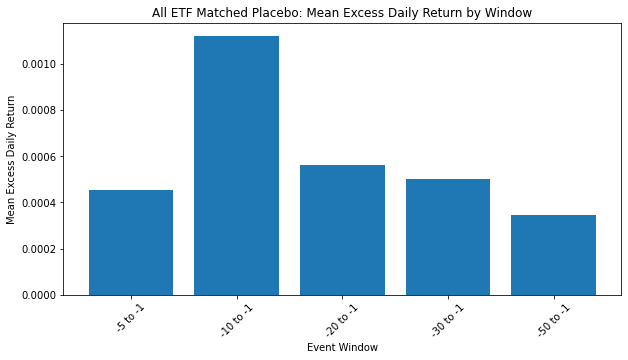

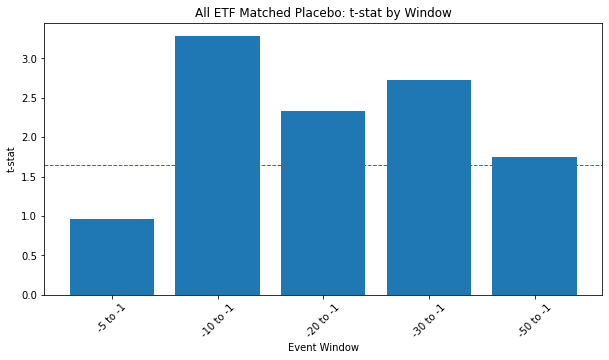

In [10]:
plot_df = all_etf_matched_window_comparison.copy()
plot_df["window"] = plot_df["entry_day"].astype(str) + " to " + plot_df["exit_day"].astype(str)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["window"], plot_df["excess_daily_return_mean"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("All ETF Matched Placebo: Mean Excess Daily Return by Window")
plt.xlabel("Event Window")
plt.ylabel("Mean Excess Daily Return")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["window"], plot_df["t_stat"])
plt.axhline(1.645, linestyle="--", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("All ETF Matched Placebo: t-stat by Window")
plt.xlabel("Event Window")
plt.ylabel("t-stat")
plt.xticks(rotation=45)
plt.show()

## 10. 分 ETF 排名：哪些 ETF 最有除息前 alpha？

這裡以 `-10 → -1` 作為主要研究窗口。如果前面全 ETF 掃描顯示其他窗口更好，可以調整 `target_window`。

In [11]:
target_window = (-10, -1)

all_etf_matched_table_target = build_event_vs_matched_placebo_table(
    event_data=all_etf_event_data,
    event_summary=event_summary,
    panel_all=panel_all,
    entry_day=target_window[0],
    exit_day=target_window[1],
    price_col="adj_close",
    fee_rate=0.0008,
    n_samples=1000,
    buffer_days=30,
    random_state=42,
    min_random_samples=30,
    use_symbol_specific_buffer=True,
)

print("target matched table shape:", all_etf_matched_table_target.shape)
display(all_etf_matched_table_target.head())

target matched table shape: (139, 22)


,event_id,symbol,entry_date,exit_date,ex_date,entry_year,entry_day,exit_day,holding_days,buffer_days_used,...,matched_placebo_mean_daily_return,matched_placebo_median_daily_return,event_excess_daily_return,event_excess_daily_return_vs_median,random_sample_count,entry_premium,exit_premium,entry_volume_ratio,dividend_yield_on_entry,etf_name
0,0050_20160728,0050,2016-07-14,2016-07-27,2016-07-28,2016,-10,-1,9,30,...,0.000498,0.000604,0.002606,0.002501,758,-0.0019,-0.0053,0.773395,0.050222,元大台灣50
1,0050_20170208,0050,2017-01-17,2017-02-07,2017-02-08,2017,-10,-1,9,30,...,0.000263,0.000085,0.001096,0.001274,618,-0.0033,-0.0045,0.527320,0.094053,元大台灣50
2,0050_20170731,0050,2017-07-17,2017-07-28,2017-07-31,2017,-10,-1,9,30,...,0.000305,0.000028,-0.000618,-0.000341,631,-0.0013,-0.0032,0.881649,0.034063,元大台灣50
3,0050_20180129,0050,2018-01-15,2018-01-26,2018-01-29,2018,-10,-1,9,30,...,-0.001352,-0.001126,0.004916,0.004689,605,-0.0044,0.0036,0.774907,0.103957,元大台灣50
4,0050_20180723,0050,2018-07-09,2018-07-20,2018-07-23,2018,-10,-1,9,30,...,-0.001171,-0.001126,0.004236,0.004190,605,0.0019,-0.0021,1.745929,0.034043,元大台灣50


In [12]:
def summarize_matched_placebo_by_symbol(
    matched_table: pd.DataFrame,
    min_events: int = 5,
) -> pd.DataFrame:
    rows = []

    if matched_table.empty:
        return pd.DataFrame()

    for symbol, g in matched_table.groupby("symbol"):
        if len(g) < min_events:
            continue

        sig = summarize_return_significance(g["event_excess_daily_return"], alternative="greater")

        row = {
            "symbol": symbol,
            "event_count": len(g),
            "actual_daily_return_mean": g["actual_daily_return"].mean(),
            "placebo_daily_return_mean": g["matched_placebo_mean_daily_return"].mean(),
            "excess_daily_return_mean": g["event_excess_daily_return"].mean(),
            "excess_daily_return_median": g["event_excess_daily_return"].median(),
            "excess_win_rate": (g["event_excess_daily_return"] > 0).mean(),
            "t_stat": sig["t_stat"],
            "p_value": sig["p_value"],
            "avg_random_sample_count": g["random_sample_count"].mean(),
        }

        if "etf_name" in g.columns:
            row["etf_name"] = g["etf_name"].dropna().astype(str).iloc[0] if g["etf_name"].notna().any() else ""

        rows.append(row)

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    return result.sort_values(["p_value", "excess_daily_return_mean"], ascending=[True, False]).reset_index(drop=True)


symbol_alpha_rank = summarize_matched_placebo_by_symbol(all_etf_matched_table_target, min_events=5)
symbol_alpha_rank.head(30)

,symbol,event_count,actual_daily_return_mean,placebo_daily_return_mean,excess_daily_return_mean,excess_daily_return_median,excess_win_rate,t_stat,p_value,avg_random_sample_count,etf_name
0,0050,20,0.002651,0.000649,0.002002,0.002288,0.650000,2.393873,0.013574,630.650000,元大台灣50
1,006208,19,0.002745,0.000349,0.002396,0.001772,0.578947,2.055225,0.027332,573.842105,富邦台50
2,00878,22,0.001422,0.000184,0.001238,0.001859,0.636364,1.458664,0.079727,393.363636,國泰永續高股息
3,00713,19,0.001214,0.000612,0.000602,-0.000080,0.473684,1.439532,0.083582,363.000000,元大台灣高息低波
4,00919,12,0.002246,0.001112,0.001134,0.001308,0.750000,1.330452,0.105146,468.666667,群益台灣精選高息
5,0056,19,0.001432,0.000286,0.001146,0.000004,0.526316,1.185607,0.125597,447.473684,元大高股息
6,0052,11,0.001391,0.000699,0.000692,-0.002505,0.454545,0.335947,0.371927,764.727273,富邦科技
7,00939,6,-0.000623,-0.000199,-0.000424,-0.000036,0.500000,-0.466380,0.669721,435.833333,統一台灣高息動能
8,00940,7,-0.001272,0.000553,-0.001826,-0.001648,0.285714,-1.627172,0.922588,309.000000,元大台灣價值高息


In [13]:
# ============================================================
# Check matched placebo coverage by symbol
# ============================================================

raw_event_count_by_symbol = (
    all_etf_event_data[["event_id", "symbol"]]
    .drop_duplicates()
    .groupby("symbol")
    .size()
    .rename("raw_event_count")
)

matched_event_count_by_symbol = (
    all_etf_matched_table_target
    .groupby("symbol")
    .size()
    .rename("matched_event_count")
)

matched_quality_by_symbol = (
    all_etf_matched_table_target
    .groupby("symbol")
    .agg(
        avg_random_sample_count=("random_sample_count", "mean"),
        min_random_sample_count=("random_sample_count", "min"),
        median_random_sample_count=("random_sample_count", "median"),
        avg_buffer_days_used=("buffer_days_used", "mean"),
    )
)

coverage = pd.concat(
    [
        raw_event_count_by_symbol,
        matched_event_count_by_symbol,
        matched_quality_by_symbol,
    ],
    axis=1,
).fillna(0)

coverage["matched_coverage_rate"] = (
    coverage["matched_event_count"] / coverage["raw_event_count"]
)

coverage = coverage.sort_values("matched_coverage_rate")

display(coverage)

,raw_event_count,matched_event_count,avg_random_sample_count,min_random_sample_count,median_random_sample_count,avg_buffer_days_used,matched_coverage_rate
symbol,,,,,,,
00929,32,4,128.250000,115,127.0,10.0,0.125000
00939,22,6,435.833333,417,431.0,10.0,0.272727
00940,22,7,309.000000,282,314.0,10.0,0.318182
0050,20,20,630.650000,594,623.5,30.0,1.000000
0052,11,11,764.727273,525,786.0,30.0,1.000000
0056,19,19,447.473684,126,235.0,30.0,1.000000
006208,19,19,573.842105,536,564.0,30.0,1.000000
00713,19,19,363.000000,142,190.0,30.0,1.000000
00878,22,22,393.363636,335,380.0,20.0,1.000000


## 11. 多重檢定校正：避免剛好挑到幸運 ETF

In [14]:
def add_multiple_testing_adjustment(df: pd.DataFrame, p_col: str = "p_value") -> pd.DataFrame:
    result = df.copy()

    if result.empty or p_col not in result.columns:
        return result

    result["p_value_bonferroni"] = (result[p_col] * len(result)).clip(upper=1)

    p = result[p_col].to_numpy()
    n = len(p)
    order = np.argsort(p)
    ranked_p = p[order]

    q = ranked_p * n / (np.arange(1, n + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    p_fdr = np.empty_like(q)
    p_fdr[order] = q

    result["p_value_fdr_bh"] = p_fdr
    result["significant_fdr_5pct"] = result["p_value_fdr_bh"] < 0.05
    result["significant_raw_5pct"] = result[p_col] < 0.05

    return result


symbol_alpha_rank = add_multiple_testing_adjustment(symbol_alpha_rank, p_col="p_value")
symbol_alpha_rank.head(30)

,symbol,event_count,actual_daily_return_mean,placebo_daily_return_mean,excess_daily_return_mean,excess_daily_return_median,excess_win_rate,t_stat,p_value,avg_random_sample_count,etf_name,p_value_bonferroni,p_value_fdr_bh,significant_fdr_5pct,significant_raw_5pct
0,0050,20,0.002651,0.000649,0.002002,0.002288,0.650000,2.393873,0.013574,630.650000,元大台灣50,0.122169,0.122169,False,True
1,006208,19,0.002745,0.000349,0.002396,0.001772,0.578947,2.055225,0.027332,573.842105,富邦台50,0.245985,0.122992,False,True
2,00878,22,0.001422,0.000184,0.001238,0.001859,0.636364,1.458664,0.079727,393.363636,國泰永續高股息,0.717541,0.188060,False,False
3,00713,19,0.001214,0.000612,0.000602,-0.000080,0.473684,1.439532,0.083582,363.000000,元大台灣高息低波,0.752241,0.188060,False,False
4,00919,12,0.002246,0.001112,0.001134,0.001308,0.750000,1.330452,0.105146,468.666667,群益台灣精選高息,0.946317,0.188395,False,False
5,0056,19,0.001432,0.000286,0.001146,0.000004,0.526316,1.185607,0.125597,447.473684,元大高股息,1.000000,0.188395,False,False
6,0052,11,0.001391,0.000699,0.000692,-0.002505,0.454545,0.335947,0.371927,764.727273,富邦科技,1.000000,0.478192,False,False
7,00939,6,-0.000623,-0.000199,-0.000424,-0.000036,0.500000,-0.466380,0.669721,435.833333,統一台灣高息動能,1.000000,0.753437,False,False
8,00940,7,-0.001272,0.000553,-0.001826,-0.001648,0.285714,-1.627172,0.922588,309.000000,元大台灣價值高息,1.000000,0.922588,False,False


## 12. ETF 類型分類

這裡先提供一個可編輯的簡易分類。

你可以逐步把常見 ETF 補上分類；未分類者會先歸為 `others`。

In [15]:
etf_category_map = {
    "0056": "high_dividend",
    "00713": "high_dividend",
    "00878": "high_dividend",
    "00919": "high_dividend",
    "00929": "high_dividend",
    "00939": "high_dividend",
    "00940": "high_dividend",
    "0050": "market_cap",
    "006208": "market_cap",
    "0052": "technology",
    "00881": "technology",
}

all_etf_matched_table_target["category"] = all_etf_matched_table_target["symbol"].map(etf_category_map).fillna("others")
symbol_alpha_rank["category"] = symbol_alpha_rank["symbol"].map(etf_category_map).fillna("others")

display(symbol_alpha_rank[["symbol", "category", "event_count", "excess_daily_return_mean", "p_value", "p_value_fdr_bh"]].head(30))

,symbol,category,event_count,excess_daily_return_mean,p_value,p_value_fdr_bh
0,0050,market_cap,20,0.002002,0.013574,0.122169
1,006208,market_cap,19,0.002396,0.027332,0.122992
2,00878,high_dividend,22,0.001238,0.079727,0.188060
3,00713,high_dividend,19,0.000602,0.083582,0.188060
4,00919,high_dividend,12,0.001134,0.105146,0.188395
5,0056,high_dividend,19,0.001146,0.125597,0.188395
6,0052,technology,11,0.000692,0.371927,0.478192
7,00939,high_dividend,6,-0.000424,0.669721,0.753437
8,00940,high_dividend,7,-0.001826,0.922588,0.922588


In [16]:
def summarize_matched_placebo_by_category(
    matched_table: pd.DataFrame,
    min_events: int = 10,
) -> pd.DataFrame:
    rows = []

    if matched_table.empty:
        return pd.DataFrame()

    for category, g in matched_table.groupby("category"):
        if len(g) < min_events:
            continue

        sig = summarize_return_significance(g["event_excess_daily_return"], alternative="greater")

        row = {
            "category": category,
            "event_count": len(g),
            "symbol_count": g["symbol"].nunique(),
            "actual_daily_return_mean": g["actual_daily_return"].mean(),
            "placebo_daily_return_mean": g["matched_placebo_mean_daily_return"].mean(),
            "excess_daily_return_mean": g["event_excess_daily_return"].mean(),
            "excess_daily_return_median": g["event_excess_daily_return"].median(),
            "excess_win_rate": (g["event_excess_daily_return"] > 0).mean(),
            "t_stat": sig["t_stat"],
            "p_value": sig["p_value"],
        }

        rows.append(row)

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    return result.sort_values(["p_value", "excess_daily_return_mean"], ascending=[True, False]).reset_index(drop=True)


category_alpha_rank = summarize_matched_placebo_by_category(all_etf_matched_table_target, min_events=10)
category_alpha_rank

,category,event_count,symbol_count,actual_daily_return_mean,placebo_daily_return_mean,excess_daily_return_mean,excess_daily_return_median,excess_win_rate,t_stat,p_value
0,market_cap,39,2,0.002697,0.000503,0.002194,0.001920,0.615385,3.121570,0.001715
1,high_dividend,89,7,0.001213,0.000508,0.000705,0.000555,0.561798,2.000655,0.024256
2,technology,11,1,0.001391,0.000699,0.000692,-0.002505,0.454545,0.335947,0.371927


## 13. 初步 Alpha Score：研究排序工具

In [17]:
if not symbol_alpha_rank.empty:
    symbol_alpha_rank["ex_dividend_alpha_score"] = (
        symbol_alpha_rank["excess_daily_return_mean"].fillna(0) * 10000 * 0.4
        + symbol_alpha_rank["excess_win_rate"].fillna(0) * 10 * 0.2
        + symbol_alpha_rank["t_stat"].fillna(0) * 0.3
        - symbol_alpha_rank["p_value_fdr_bh"].fillna(1) * 10 * 0.1
    )

    symbol_alpha_rank = symbol_alpha_rank.sort_values("ex_dividend_alpha_score", ascending=False).reset_index(drop=True)

symbol_alpha_rank.head(30)

,symbol,event_count,actual_daily_return_mean,placebo_daily_return_mean,excess_daily_return_mean,excess_daily_return_median,excess_win_rate,t_stat,p_value,avg_random_sample_count,etf_name,p_value_bonferroni,p_value_fdr_bh,significant_fdr_5pct,significant_raw_5pct,category,ex_dividend_alpha_score
0,006208,19,0.002745,0.000349,0.002396,0.001772,0.578947,2.055225,0.027332,573.842105,富邦台50,0.245985,0.122992,False,True,market_cap,11.234079
1,0050,20,0.002651,0.000649,0.002002,0.002288,0.650000,2.393873,0.013574,630.650000,元大台灣50,0.122169,0.122169,False,True,market_cap,9.904086
2,00878,22,0.001422,0.000184,0.001238,0.001859,0.636364,1.458664,0.079727,393.363636,國泰永續高股息,0.717541,0.188060,False,False,high_dividend,6.473196
3,00919,12,0.002246,0.001112,0.001134,0.001308,0.750000,1.330452,0.105146,468.666667,群益台灣精選高息,0.946317,0.188395,False,False,high_dividend,6.246453
4,0056,19,0.001432,0.000286,0.001146,0.000004,0.526316,1.185607,0.125597,447.473684,元大高股息,1.000000,0.188395,False,False,high_dividend,5.803556
5,00713,19,0.001214,0.000612,0.000602,-0.000080,0.473684,1.439532,0.083582,363.000000,元大台灣高息低波,0.752241,0.188060,False,False,high_dividend,3.600368
6,0052,11,0.001391,0.000699,0.000692,-0.002505,0.454545,0.335947,0.371927,764.727273,富邦科技,1.000000,0.478192,False,False,technology,3.300575
7,00939,6,-0.000623,-0.000199,-0.000424,-0.000036,0.500000,-0.466380,0.669721,435.833333,統一台灣高息動能,1.000000,0.753437,False,False,high_dividend,-1.589666
8,00940,7,-0.001272,0.000553,-0.001826,-0.001648,0.285714,-1.627172,0.922588,309.000000,元大台灣價值高息,1.000000,0.922588,False,False,high_dividend,-8.142230


## 14. 條件式 Alpha：低進場量能 / Premium Filter 初步檢查

In [18]:
def run_condition_filter_on_matched_table(
    matched_table: pd.DataFrame,
    condition_col: str,
    quantile: float = 0.5,
    direction: str = "below",
) -> pd.Series:
    df = matched_table.copy()

    if condition_col not in df.columns:
        return pd.Series({"error": f"{condition_col} not in matched_table"})

    threshold = df[condition_col].quantile(quantile)

    if direction == "below":
        tmp = df[df[condition_col] <= threshold]
        condition_name = f"{condition_col}_below_q{quantile}"
    else:
        tmp = df[df[condition_col] >= threshold]
        condition_name = f"{condition_col}_above_q{quantile}"

    sig = summarize_return_significance(tmp["event_excess_daily_return"], alternative="greater")

    return pd.Series({
        "condition": condition_name,
        "threshold": threshold,
        "event_count": len(tmp),
        "symbol_count": tmp["symbol"].nunique() if not tmp.empty else 0,
        "actual_daily_return_mean": tmp["actual_daily_return"].mean(),
        "placebo_daily_return_mean": tmp["matched_placebo_mean_daily_return"].mean(),
        "excess_daily_return_mean": tmp["event_excess_daily_return"].mean(),
        "excess_daily_return_median": tmp["event_excess_daily_return"].median(),
        "excess_win_rate": (tmp["event_excess_daily_return"] > 0).mean(),
        "t_stat": sig["t_stat"],
        "p_value": sig["p_value"],
    })


condition_results = []

for condition_col in ["entry_volume_ratio", "entry_premium", "dividend_yield_on_entry"]:
    if condition_col in all_etf_matched_table_target.columns:
        condition_results.append(run_condition_filter_on_matched_table(all_etf_matched_table_target, condition_col, 0.5, "below"))
        condition_results.append(run_condition_filter_on_matched_table(all_etf_matched_table_target, condition_col, 0.5, "above"))

condition_filter_result = pd.DataFrame(condition_results)
condition_filter_result.sort_values(["p_value", "excess_daily_return_mean"], ascending=[True, False])

,condition,threshold,event_count,symbol_count,actual_daily_return_mean,placebo_daily_return_mean,excess_daily_return_mean,excess_daily_return_median,excess_win_rate,t_stat,p_value
5,dividend_yield_on_entry_above_q0.5,0.023014,70,7,0.001718,0.000474,0.001244,0.000763,0.571429,2.540614,0.006660
0,entry_volume_ratio_below_q0.5,1.298983,70,10,0.001852,0.000653,0.001199,0.000563,0.585714,2.509701,0.007217
3,entry_premium_above_q0.5,0.000800,66,8,0.001794,0.000568,0.001226,0.000940,0.560606,2.502432,0.007429
4,dividend_yield_on_entry_below_q0.5,0.023014,70,9,0.001686,0.000515,0.001171,0.000670,0.571429,2.330902,0.011344
2,entry_premium_below_q0.5,0.000800,66,10,0.001706,0.000504,0.001202,0.001009,0.590909,2.281182,0.012911
1,entry_volume_ratio_above_q0.5,1.298983,70,9,0.001422,0.000391,0.001031,0.000758,0.557143,2.128830,0.018420


## 15. Robustness：buffer days 敏感度

In [19]:
# ============================================================
# Robustness: monthly ETF buffer sensitivity
# ============================================================

monthly_buffer_days_list = [5, 7, 10, 15, 20]
monthly_buffer_sensitivity_results = []

for monthly_buffer_days in monthly_buffer_days_list:
    # 暫時覆蓋月配 buffer 設定
    def get_buffer_days_by_symbol_temp(symbol: str) -> int:
        symbol = fix_tw_etf_symbol(symbol)

        if symbol in MONTHLY_DIVIDEND_SYMBOLS:
            return monthly_buffer_days

        if symbol in QUARTERLY_OR_HIGH_FREQ_SYMBOLS:
            return QUARTERLY_BUFFER_DAYS

        return DEFAULT_BUFFER_DAYS

    # 在這個 loop 裡手動建立 matched table
    holding_days = target_window[1] - target_window[0]

    actual_trades = calculate_event_trade_return_enriched(
        event_data=all_etf_event_data,
        price_col="adj_close",
        entry_day=target_window[0],
        exit_day=target_window[1],
        fee_rate=0.0008,
    )

    rows = []

    for i, trade in actual_trades.iterrows():
        symbol = fix_tw_etf_symbol(trade["symbol"])
        entry_year = pd.to_datetime(trade["entry_date"]).year
        actual_daily_return = trade["daily_net_return"]

        buffer_days_used = get_buffer_days_by_symbol_temp(symbol)

        random_returns = generate_matched_random_windows_for_event(
            panel_all=panel_all,
            event_summary=event_summary,
            symbol=symbol,
            event_year=entry_year,
            holding_days=holding_days,
            n_samples=1000,
            buffer_days=buffer_days_used,
            price_col="adj_close",
            fee_rate=0.0008,
            random_state=42 + i,
        )

        if len(random_returns) < 30:
            continue

        row = {
            "event_id": trade["event_id"],
            "symbol": symbol,
            "entry_year": entry_year,
            "buffer_days_used": buffer_days_used,
            "actual_daily_return": actual_daily_return,
            "matched_placebo_mean_daily_return": random_returns.mean(),
            "event_excess_daily_return": actual_daily_return - random_returns.mean(),
            "random_sample_count": len(random_returns),
        }

        rows.append(row)

    table = pd.DataFrame(rows)

    sig = summarize_return_significance(
        table["event_excess_daily_return"],
        alternative="greater",
    )

    monthly_rows = table[table["symbol"].isin(MONTHLY_DIVIDEND_SYMBOLS)]

    monthly_sig = summarize_return_significance(
        monthly_rows["event_excess_daily_return"],
        alternative="greater",
    ) if not monthly_rows.empty else pd.Series({
        "t_stat": np.nan,
        "p_value": np.nan,
    })

    monthly_buffer_sensitivity_results.append({
        "monthly_buffer_days": monthly_buffer_days,
        "total_event_count": len(table),
        "total_symbol_count": table["symbol"].nunique() if not table.empty else 0,
        "total_excess_daily_return_mean": table["event_excess_daily_return"].mean(),
        "total_excess_win_rate": (table["event_excess_daily_return"] > 0).mean(),
        "total_avg_random_sample_count": table["random_sample_count"].mean() if not table.empty else np.nan,
        "total_t_stat": sig["t_stat"],
        "total_p_value": sig["p_value"],

        "monthly_event_count": len(monthly_rows),
        "monthly_symbol_count": monthly_rows["symbol"].nunique() if not monthly_rows.empty else 0,
        "monthly_excess_daily_return_mean": monthly_rows["event_excess_daily_return"].mean() if not monthly_rows.empty else np.nan,
        "monthly_excess_win_rate": (monthly_rows["event_excess_daily_return"] > 0).mean() if not monthly_rows.empty else np.nan,
        "monthly_avg_random_sample_count": monthly_rows["random_sample_count"].mean() if not monthly_rows.empty else np.nan,
        "monthly_t_stat": monthly_sig["t_stat"],
        "monthly_p_value": monthly_sig["p_value"],
    })

monthly_buffer_sensitivity = pd.DataFrame(monthly_buffer_sensitivity_results)

display(monthly_buffer_sensitivity)

,monthly_buffer_days,total_event_count,total_symbol_count,total_excess_daily_return_mean,total_excess_win_rate,total_avg_random_sample_count,total_t_stat,total_p_value,monthly_event_count,monthly_symbol_count,monthly_excess_daily_return_mean,monthly_excess_win_rate,monthly_avg_random_sample_count,monthly_t_stat,monthly_p_value
0,5,198,10,0.000874,0.570707,416.272727,2.790342,0.002891,76,3,0.000078,0.552632,273.907895,0.142176,0.443661
1,7,195,10,0.001056,0.579487,363.892308,3.183067,0.000849,73,3,0.000529,0.575342,128.136986,0.842102,0.201260
2,10,139,10,0.001122,0.568345,481.266187,3.286991,0.000642,17,3,-0.000665,0.470588,311.235294,-0.997500,0.833315
3,15,139,10,0.001129,0.568345,477.726619,3.308480,0.000598,17,3,-0.000602,0.470588,282.294118,-0.886902,0.805866
4,20,139,10,0.001110,0.561151,475.525180,3.251825,0.000721,17,3,-0.000761,0.411765,264.294118,-1.166018,0.869653


## 16. 輸出結果

In [21]:
all_etf_event_data.to_csv(OUTPUT_DIR / "all_etf_ex_dividend_event_data.csv", index=False, encoding="utf-8-sig")
skipped_events.to_csv(OUTPUT_DIR / "all_etf_ex_dividend_skipped_events.csv", index=False, encoding="utf-8-sig")
raw_window_comparison.to_csv(OUTPUT_DIR / "all_etf_raw_window_comparison.csv", index=False, encoding="utf-8-sig")
all_etf_matched_window_comparison.to_csv(OUTPUT_DIR / "all_etf_matched_window_comparison.csv", index=False, encoding="utf-8-sig")
all_etf_matched_table_target.to_csv(OUTPUT_DIR / "all_etf_matched_placebo_table_target_window.csv", index=False, encoding="utf-8-sig")
symbol_alpha_rank.to_csv(OUTPUT_DIR / "all_etf_ex_dividend_alpha_rank_by_symbol.csv", index=False, encoding="utf-8-sig")
category_alpha_rank.to_csv(OUTPUT_DIR / "all_etf_ex_dividend_alpha_rank_by_category.csv", index=False, encoding="utf-8-sig")
condition_filter_result.to_csv(OUTPUT_DIR / "all_etf_condition_filter_result.csv", index=False, encoding="utf-8-sig")
buffer_sensitivity.to_csv(OUTPUT_DIR / "all_etf_matched_placebo_buffer_sensitivity.csv", index=False, encoding="utf-8-sig")

print("Saved outputs to:", OUTPUT_DIR)

NameError: name 'buffer_sensitivity' is not defined

In [ ]:
raw_event_count_by_symbol = (
    all_etf_event_data[["event_id", "symbol"]]
    .drop_duplicates()
    .groupby("symbol")
    .size()
    .rename("raw_event_count")
)

matched_event_count_by_symbol = (
    all_etf_matched_table_target
    .groupby("symbol")
    .size()
    .rename("matched_event_count")
)

coverage = pd.concat(
    [raw_event_count_by_symbol, matched_event_count_by_symbol],
    axis=1
).fillna(0)

coverage["matched_coverage_rate"] = (
    coverage["matched_event_count"] / coverage["raw_event_count"]
)

coverage.to_csv(
    OUTPUT_DIR / "all_etf_matched_placebo_coverage_by_symbol.csv",
    encoding="utf-8-sig",
)

monthly_buffer_sensitivity.to_csv(
    OUTPUT_DIR / "all_etf_monthly_buffer_sensitivity.csv",
    index=False,
    encoding="utf-8-sig",
)

display(coverage.sort_values("matched_coverage_rate"))

## 17. 研究結論模板

跑完後可以依結果填寫：

1. 全 ETF 在 `-10 → -1` 是否存在顯著 matched placebo alpha？
2. `-10 → -1` 是否比 `-30 → -1`、`-50 → -1` 更具單位時間事件 alpha？
3. alpha 是否集中於特定 ETF？
4. alpha 是否集中於特定類型，例如高股息、科技、市值型、債券型？
5. 低進場量能、低 premium 或其他 filter 是否能提升顯著性？
6. 多重檢定校正後，還有哪些 ETF 仍顯著？

建議報告語句：

> 本研究以同 ETF、同年份、非除息期間作為 matched placebo，檢驗除息前事件窗口是否具備相對於自身正常期間的超額每日報酬。相較於直接使用 0050 作為 benchmark，此方法能控制年度行情、ETF 個別體質與市場風格差異，更適合判斷除息事件是否存在事件型 alpha。